# Test results & coverage

Test pass rates, convergence to green, intents coverage and code coverage per model, from `TestResults/` (+ `UserIntents/` as the intent denominator).

In [13]:
STORY_ID = "CPD-LC-001-009"

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tdd_results as tdd

tdd.setup_theme()
# Clear the per-session label cache and warning list first: re-running this
# cell after dropping new results into the trees would otherwise reuse stale
# model labels and count the same load warning once per re-run.
tdd.reset_caches()
data = tdd.load_all(STORY_ID)
MODELS = tdd.discover_models(STORY_ID)
if not MODELS:
    print(f"no results found for {STORY_ID!r}; stories present in the result "
          f"trees: {tdd.discover_stories()}")
PAL = tdd.model_palette(MODELS)        # fixed model -> color, used everywhere
HUE = list(PAL)                        # fixed hue_order, used everywhere

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print(f"story: {STORY_ID} | models: {MODELS}")
print("palette:", PAL)
if tdd.load_warnings:
    print(f"{len(tdd.load_warnings)} load warnings -> tdd.load_warnings")

story: CPD-LC-001-009 | models: ['Kimi-K2.5', 'Qwen3.7-max']
palette: {'Kimi-K2.5': '#2a78d6', 'Qwen3.7-max': '#1baf7a'}
7 load warnings -> tdd.load_warnings


## Data integrity gate

Same gate as `00_overview_scorecard`: identity drift absorbed, evidence
accounted for, and any metric that has stopped discriminating flagged before
the charts are read.


In [15]:
summ = tdd.iteration_summary(STORY_ID, data)
sig = tdd.discrimination(summ)
drift = tdd.audit_identity(STORY_ID)
dead = sig[sig["status"].isin(["ABSENT", "ALL-NA", "CONSTANT"])]
print(f"identity : {len(drift)} disagreements, {(~drift['reconciles']).sum() if not drift.empty else 0} unreconcilable")
print(f"signal   : {len(sig) - len(dead)}/{len(sig)} metrics discriminate")
if not dead.empty:
    display(dead)


identity : 0 disagreements, 0 unreconcilable
signal   : 18/24 metrics discriminate


,metric,family,provenance,status,distinct,na_share
3,e2e_probe_pass_rate,B behavioural,tool-measured,CONSTANT,1,0.0
9,red_first,C convergence,tool-measured,CONSTANT,1,0.0
11,evidence_completeness,E evidence,derived,CONSTANT,1,0.0
16,ref_all_green,Q quality,self-reported,CONSTANT,1,0.0
19,layer_balance,V verification,tool-measured,CONSTANT,1,0.0
20,layer_coverage,V verification,tool-measured,CONSTANT,1,0.0


## Final test pass rate per iteration

Where each iteration *ended*. Markers show actual iterations; a flat line at
1.0 means every iteration finished fully green.

**Chart & table columns** — chart: `iteration` (x); `pass rate (final run)` (y) — passed÷total of the run's last test execution; color — model. Table: the same final runs with `total`, `passed`, `failed`, `skipped` test-method counts.

,model,iteration,total,passed,failed,skipped
0,Kimi-K2.5,1,118,118,0,0
1,Kimi-K2.5,2,113,113,0,0
2,Kimi-K2.5,3,105,105,0,0
3,Kimi-K2.5,4,118,118,0,0
4,Kimi-K2.5,5,118,118,0,0
5,Kimi-K2.5,6,103,103,0,0
6,Qwen3.7-max,1,117,117,0,0
7,Qwen3.7-max,3,118,118,0,0
8,Qwen3.7-max,4,118,118,0,0
9,Qwen3.7-max,5,118,118,0,0


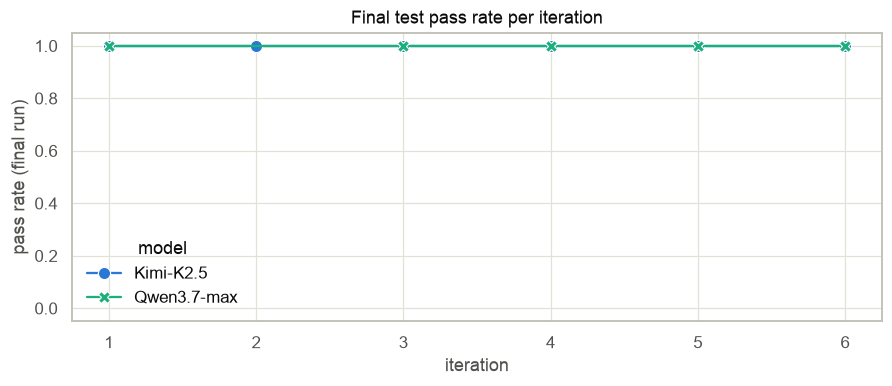

In [16]:
t = data["test"]
tfin = tdd.finals(t)
if tfin.empty:
    print("No test data.")
else:
    fig, ax = plt.subplots(figsize=(8, 3.4))
    sns.lineplot(data=tfin, x="iteration", y="pass_rate", hue="model",
                 style="model", hue_order=HUE, style_order=HUE, palette=PAL,
                 markers=True, dashes=False, estimator=None, markersize=8, ax=ax)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("pass rate (final run)")
    ax.set_title("Final test pass rate per iteration")
    display(tfin[["model", "iteration", "total", "passed", "failed", "skipped"]]
            .sort_values(["model", "iteration"]).reset_index(drop=True))

## Test outcome composition (final runs, all iterations pooled)

Left: proportions — how green is each model. Right: absolute counts —
models emit different numbers of tests, which proportions alone hide.

**Chart columns** — `model` (y); bar segments — final-run test methods by outcome (`passed` green / `failed` red / `skipped` gray), summed over that model's runs; left panel x — proportion of outcomes (0–1); right panel x — absolute test counts (segment labels).

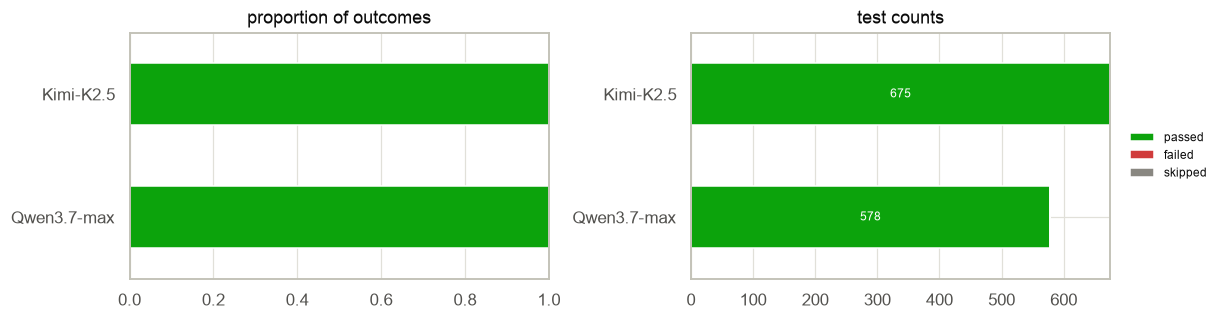

In [17]:
if tfin.empty:
    print("No test data.")
else:
    comp = tfin.groupby("model")[["passed", "failed", "skipped"]].sum().reindex(HUE)
    colors = [tdd.OUTCOME_COLORS[c] for c in comp.columns]
    frac = comp.div(comp.sum(axis=1), axis=0)
    fig, axes = plt.subplots(1, 2, figsize=(11, 2.8))
    frac.plot(kind="barh", stacked=True, color=colors, ax=axes[0], legend=False)
    axes[0].set_title("proportion of outcomes")
    axes[0].set_xlim(0, 1)
    comp.plot(kind="barh", stacked=True, color=colors, ax=axes[1])
    for container in axes[1].containers:
        axes[1].bar_label(container, label_type="center", fontsize=8, color="white",
                          labels=[f"{int(v)}" if v else "" for v in container.datavalues])
    axes[1].set_title("test counts")
    axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    for ax in axes:
        ax.set_ylabel("")
        ax.invert_yaxis()

## Convergence to green within each iteration

Pass rate at every successive test execution. How quickly does each model
climb to 1.0 — and does it stay there?

**Chart columns** — one panel per `iteration`: `attempt #` (x) — chronological test execution within the run; `pass rate` (y) — passed÷total at that attempt; line color — model; dotted line — fully green (1.0).

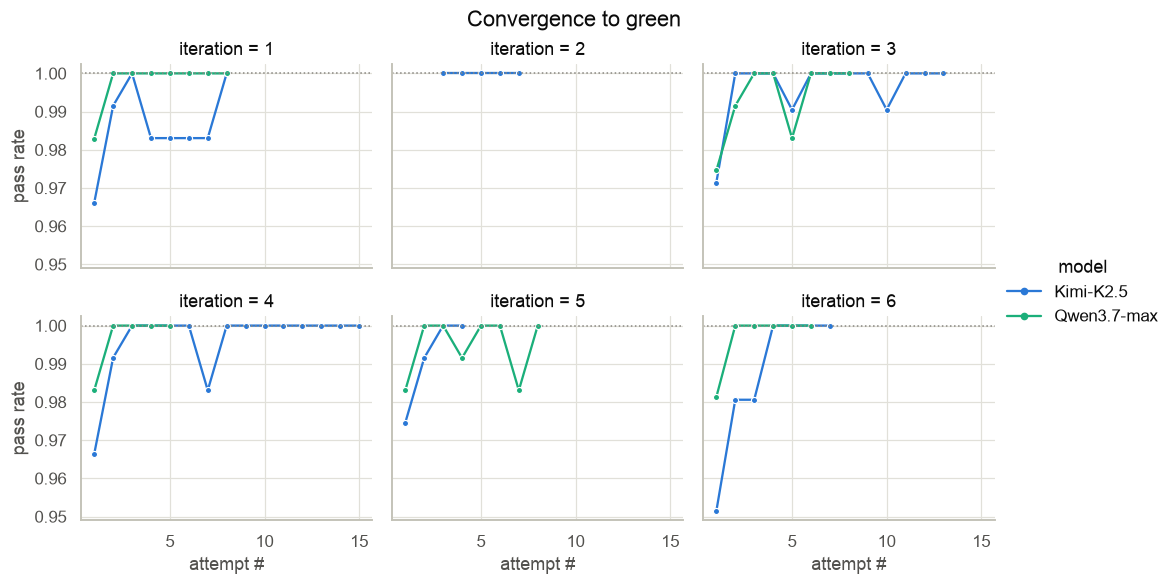

In [18]:
if t.empty:
    print("No test data.")
else:
    g = sns.relplot(data=t, kind="line", x="attempt", y="pass_rate",
                    hue="model", col="iteration", col_wrap=3, hue_order=HUE,
                    palette=PAL, estimator=None, marker="o", markersize=4,
                    height=2.6, aspect=1.2)
    for ax in g.axes.flat:
        ax.axhline(1.0, ls=":", color=tdd.INK["muted"], lw=1)
    g.set_axis_labels("attempt #", "pass rate")
    g.figure.suptitle("Convergence to green", y=1.02)

## Attempts until first fully-green test run

The concrete cost of reaching green. Cells that never reached a successful
run in an iteration are listed below the chart.

**Chart columns** — `iteration` (x); `attempts to first green` (y) — earliest `attempt #` whose test execution reported status `success`, i.e. every test passing (lower = cheaper); bar color — model. The list below names runs that never got there (`model`, `iteration`).

Every (model, iteration) cell eventually reached green.


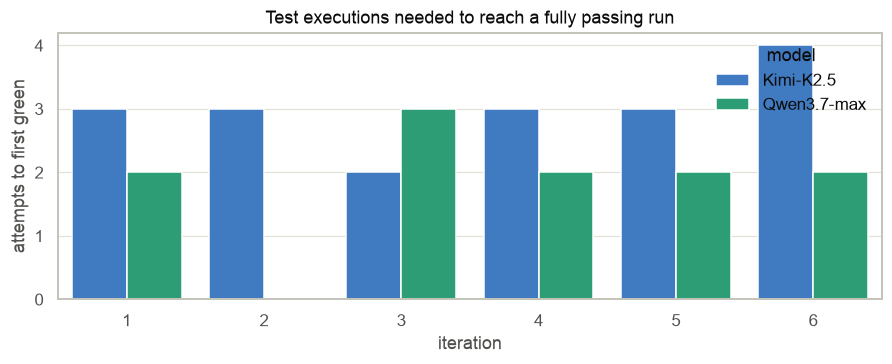

In [19]:
if t.empty:
    print("No test data.")
else:
    green = t[t["status"] == "success"]
    first = (green.groupby(["model", "iteration"])["attempt"].min()
                  .reset_index(name="attempts_to_green"))
    if first.empty:
        print("No iteration ever reached a green run.")
    else:
        fig, ax = plt.subplots(figsize=(8, 3.2))
        sns.barplot(data=first, x="iteration", y="attempts_to_green",
                    hue="model", hue_order=HUE, palette=PAL, ax=ax)
        ax.set_ylabel("attempts to first green")
        ax.set_title("Test executions needed to reach a fully passing run")
    cells = t[["model", "iteration"]].drop_duplicates()
    never = cells.merge(first, on=["model", "iteration"], how="left")
    never = never[never["attempts_to_green"].isna()]
    if never.empty:
        print("Every (model, iteration) cell eventually reached green.")
    else:
        print("Never reached green:")
        display(never[["model", "iteration"]].reset_index(drop=True))

## Intent coverage per layer (tool-measured)

Does the suite actually cover the story, and is the effort spread the way the
intents are?

Both sides of this ratio are measured, not reported. Emitted test methods come
from the final run's VSTest `.trx`, attributed to an architectural layer by
assembly name; the denominator is the confirmed-intent count per layer in
`UserIntents/`. The test-generation stage also reports an `intentsConfirmed`
of its own — it is plotted alongside as a dashed marker so a model that
*claims* more coverage than it emitted is visible, but it is never the
measurement.

**Chart & table columns** — left: `tests / intent` per layer (bar), 1.0 = one
test method per confirmed intent, dashed line at parity; right: `layer_balance`
per run (1.0 = effort matched the intent distribution exactly). Table:
per-layer test counts, the story's intent counts, `tests_per_intent`,
`layer_coverage` (share of layers at or above parity) and the agent's own
`tg_test_methods` for comparison.


,model,iteration,test_methods,tests_per_intent,layer_coverage,layer_balance,tg_test_methods,tests_Domain,tests_Application,tests_Infrastructure,tests_Presentation,intents_total,claimed_minus_emitted
0,Kimi-K2.5,1,118,3.933,1.0,0.0,30.0,66,19,13,20,30,-88.0
1,Kimi-K2.5,2,113,3.767,1.0,0.0,35.0,69,19,10,15,30,-78.0
2,Kimi-K2.5,3,105,3.500,1.0,0.0,26.0,53,19,13,20,30,-79.0
3,Kimi-K2.5,4,118,3.933,1.0,0.0,30.0,66,19,14,19,30,-88.0
4,Kimi-K2.5,5,118,3.933,1.0,0.0,30.0,66,19,13,20,30,-88.0
5,Kimi-K2.5,6,103,3.433,1.0,0.0,27.0,51,19,13,20,30,-76.0
6,Qwen3.7-max,1,117,3.900,1.0,0.0,23.0,66,19,13,19,30,-94.0
7,Qwen3.7-max,3,118,3.933,1.0,0.0,22.0,66,19,13,20,30,-96.0
8,Qwen3.7-max,4,118,3.933,1.0,0.0,21.0,66,19,13,20,30,-97.0
9,Qwen3.7-max,5,118,3.933,1.0,0.0,21.0,66,19,13,20,30,-97.0


confirmed intents per layer: {'Application': 6, 'Domain': 14, 'Infrastructure': 5, 'Presentation': 5}
note: stage self-report differs from the .trx count by up to 97 test methods -- the chart uses the .trx count


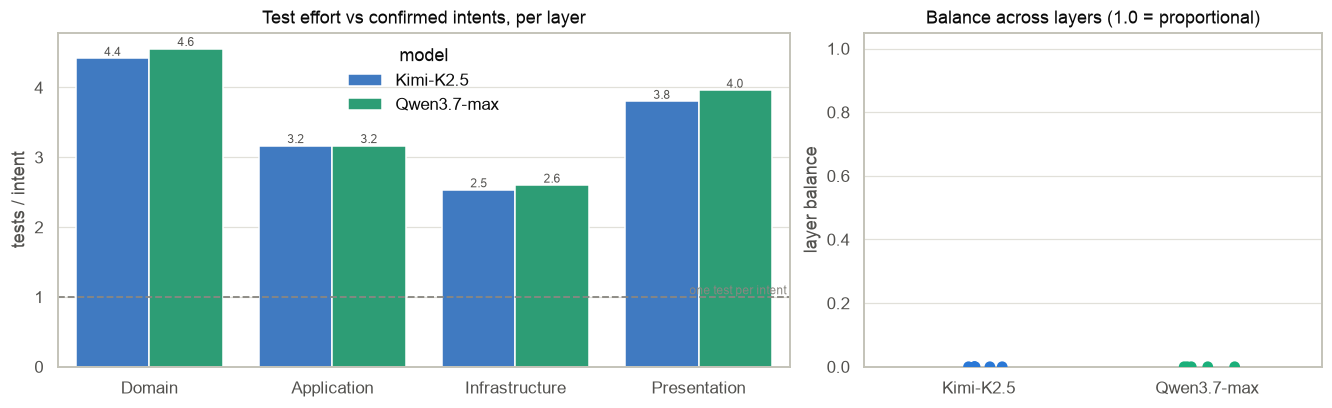

In [20]:
lc = summ[["model", "iteration", "test_methods", "tests_per_intent",
           "layer_coverage", "layer_balance", "tg_test_methods"]
          + [f"tests_{l}" for l in tdd.LAYERS]].copy()
want = tdd.intents_by_layer(STORY_ID)

if lc.empty or not want:
    print("No test or intent data for this section.")
else:
    per_layer = (lc.melt(id_vars=["model", "iteration"],
                         value_vars=[f"tests_{l}" for l in tdd.LAYERS],
                         var_name="layer", value_name="n_tests")
                   .assign(layer=lambda d: d["layer"].str.removeprefix("tests_")))
    per_layer["ratio"] = per_layer.apply(
        lambda r: r["n_tests"] / want[r["layer"]] if want.get(r["layer"]) else np.nan,
        axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6),
                             gridspec_kw={"width_ratios": [1.6, 1]})
    sns.barplot(data=per_layer, x="layer", y="ratio", hue="model", hue_order=HUE,
                palette=PAL, order=list(tdd.LAYERS), estimator="mean",
                errorbar=None, ax=axes[0])
    axes[0].axhline(1.0, ls="--", lw=1.2, color=tdd.INK["muted"])
    axes[0].text(0.995, 1.0, " one test per intent", transform=axes[0].get_yaxis_transform(),
                 ha="right", va="bottom", fontsize=8, color=tdd.INK["muted"])
    axes[0].set_ylabel("tests / intent")
    axes[0].set_xlabel("")
    axes[0].set_title("Test effort vs confirmed intents, per layer")
    tdd.label_bars(axes[0], fmt="%.1f")

    sns.stripplot(data=lc, x="model", y="layer_balance", order=HUE, hue="model",
                  hue_order=HUE, palette=PAL, legend=False, size=7, jitter=0.12,
                  ax=axes[1])
    axes[1].set_ylim(0, 1.05)
    axes[1].set_ylabel("layer balance")
    axes[1].set_xlabel("")
    axes[1].set_title("Balance across layers (1.0 = proportional)")

    intents_total = sum(want.values())
    tbl = lc.assign(intents_total=intents_total,
                    claimed_minus_emitted=lc["tg_test_methods"] - lc["test_methods"])
    display(tbl.round(3).sort_values(["model", "iteration"]))
    print("confirmed intents per layer:", want)
    gap = tbl["claimed_minus_emitted"].abs().max()
    if pd.notna(gap) and gap > 0:
        print(f"note: stage self-report differs from the .trx count by up to "
              f"{gap:.0f} test methods -- the chart uses the .trx count")


## Coverage per iteration (final runs)

Line rate solid, branch rate dashed — same 0–1 scale, so one axis is honest.

**Chart & table columns** — chart: `iteration` (x); `coverage rate` (y, 0–1) — from the run's final coverage report; color — model; line style — kind (`line_rate` solid, `branch_rate` dashed). Table: final `line_rate` per `iteration` (rows) × model (columns).

model,Kimi-K2.5,Qwen3.7-max
iteration,,
1,0.743,0.749
2,0.643,NaN
3,0.723,0.727
4,0.764,0.756
5,0.755,0.747
6,0.736,0.741


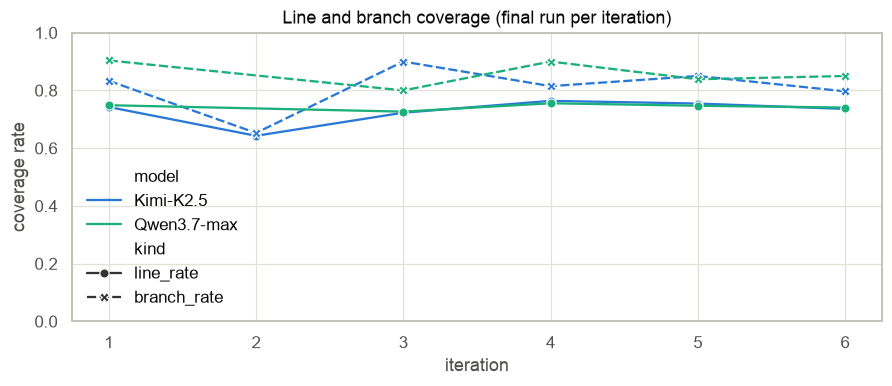

In [21]:
cov = data["coverage"]
if cov.empty:
    print("No coverage data.")
else:
    covl = cov.melt(id_vars=["model", "iteration"],
                    value_vars=["line_rate", "branch_rate"],
                    var_name="kind", value_name="rate")
    fig, ax = plt.subplots(figsize=(8, 3.4))
    sns.lineplot(data=covl, x="iteration", y="rate", hue="model", style="kind",
                 hue_order=HUE, palette=PAL, markers=True, estimator=None, ax=ax)
    ax.set_ylim(0, 1)
    ax.set_ylabel("coverage rate")
    ax.set_title("Line and branch coverage (final run per iteration)")
    display(cov.pivot_table(index="iteration", columns="model",
                            values="line_rate").round(3))

## Coverage distribution across all executions

ECDF over every measured execution: reads as "what share of runs reached at
most X coverage". Curves further right are better.

**Chart columns** — `line coverage rate` (x, 0–1) — of every coverage-bearing execution, retries included; `proportion` (y) — share of that model's executions with coverage ≤ x; line color — model.

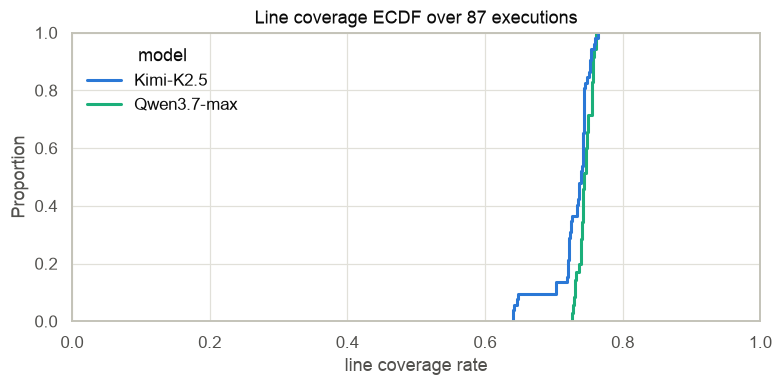

In [22]:
cov_all = tdd.load_coverage(STORY_ID, finals_only=False)
if cov_all.empty:
    print("No coverage data.")
else:
    fig, ax = plt.subplots(figsize=(7, 3.4))
    sns.ecdfplot(data=cov_all, x="line_rate", hue="model", hue_order=HUE,
                 palette=PAL, lw=2, ax=ax)
    ax.set_xlim(0, 1)
    ax.set_xlabel("line coverage rate")
    ax.set_title(f"Line coverage ECDF over {len(cov_all)} executions")

## Per-test durations (final runs)

Log-ish scale: durations are heavy-tailed. Consistently slow suites cost
wall-clock on every retry.

**Chart columns** — `model` (x); `test duration (s)` (y, symlog) — wall-clock of each individual test-method result from the final runs' `.trx` files; box — median/IQR; dots — test methods.

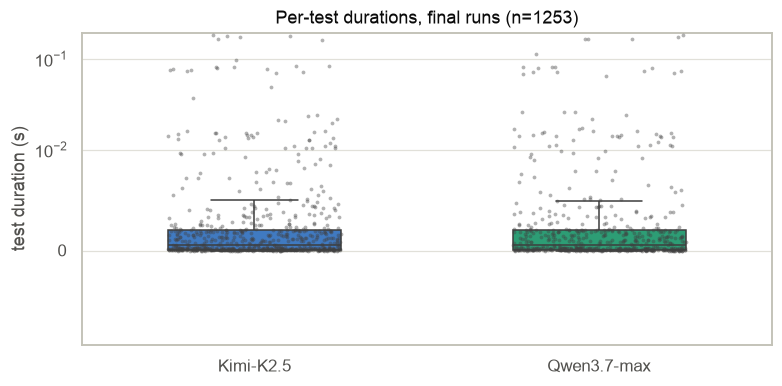

In [23]:
trx = data["trx"]
if trx.empty:
    print("No .trx data.")
else:
    fig, ax = plt.subplots(figsize=(7, 3.4))
    sns.boxplot(data=trx, x="model", y="duration_s", hue="model", order=HUE,
                hue_order=HUE, palette=PAL, legend=False, width=0.5,
                showfliers=False, ax=ax)
    sns.stripplot(data=trx, x="model", y="duration_s", order=HUE, color=".25",
                  size=2.5, alpha=0.4, jitter=0.25, ax=ax)
    ax.set_yscale("symlog", linthresh=0.01)
    ax.set_ylabel("test duration (s)")
    ax.set_xlabel("")
    ax.set_title(f"Per-test durations, final runs (n={len(trx)})")

## Sanity checks

In [24]:
if not t.empty:
    tf = tdd.finals(t)
    assert tf.groupby(["story", "model", "iteration"]).size().max() == 1
    assert tf["pass_rate"].between(0, 1, inclusive="both").all() or tf["pass_rate"].isna().any()
if not data["coverage"].empty:
    assert data["coverage"]["line_rate"].between(0, 1).all()
    assert data["coverage"]["branch_rate"].between(0, 1).all()
assert summ["model"].isin(HUE).all(), "identity drift leaked into the master table"
assert drift.empty or drift["reconciles"].all(), "misfiled results present"
if not lc.empty:
    assert (lc["layer_balance"].dropna() <= 1.0).all(), "layer balance must stay <= 1"
    assert lc["test_methods"].fillna(0).ge(0).all()
print(f"sanity checks passed | {len(tdd.load_warnings)} load warnings | "
      f"{len(dead)} metrics without signal")


sanity checks passed | 17 load warnings | 6 metrics without signal
